In [150]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

## Historical VaR & CVaR

In [151]:
nav = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\nav_history_clean.csv")
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [152]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [153]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [154]:
nav["date"] = pd.to_datetime(nav["date"])

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [155]:
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [156]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [157]:
var_results = []

for fund, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    # 5th percentile (95% Historical VaR)
    var95 = np.percentile(returns, 5)

    # Average of returns below VaR
    cvar95 = returns[returns <= var95].mean()

    var_results.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_df = pd.DataFrame(var_results)

var_df.head(10)

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459
5,101208,-0.000269,-0.000422
6,102885,-0.012613,-0.015490
7,102886,-0.019220,-0.023251
8,102887,-0.015232,-0.019411
9,118632,-0.013954,-0.017619


In [158]:
var_df.to_csv("../data/processed/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


## Rolling 90-Day Sharpe Ratio

In [159]:
fund = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\fund_master_clean.csv")
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [160]:
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth


In [161]:
nav[["amfi_code", "scheme_name"]].drop_duplicates().head(10)

,amfi_code,scheme_name
0,100016,HDFC Top 100 Fund - Regular Plan - Growth
1150,100025,HDFC Short Term Debt Fund - Regular - Growth
2300,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3450,101206,ABSL Frontline Equity Fund - Regular - Growth
4600,101207,ABSL Small Cap Fund - Regular - Growth
5750,101208,ABSL Liquid Fund - Regular - Growth
6900,102885,UTI Nifty 50 Index Fund - Regular - Growth
8050,102886,UTI Mid Cap Fund - Regular - Growth
9200,102887,UTI Flexi Cap Fund - Regular - Growth
10350,118632,Nippon India Large Cap Fund - Regular - Growth


In [162]:
top5_funds = nav["scheme_name"].drop_duplicates().head(5)

top5_funds

0               HDFC Top 100 Fund - Regular Plan - Growth
1150         HDFC Short Term Debt Fund - Regular - Growth
2300    HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3450        ABSL Frontline Equity Fund - Regular - Growth
4600               ABSL Small Cap Fund - Regular - Growth
Name: scheme_name, dtype: str

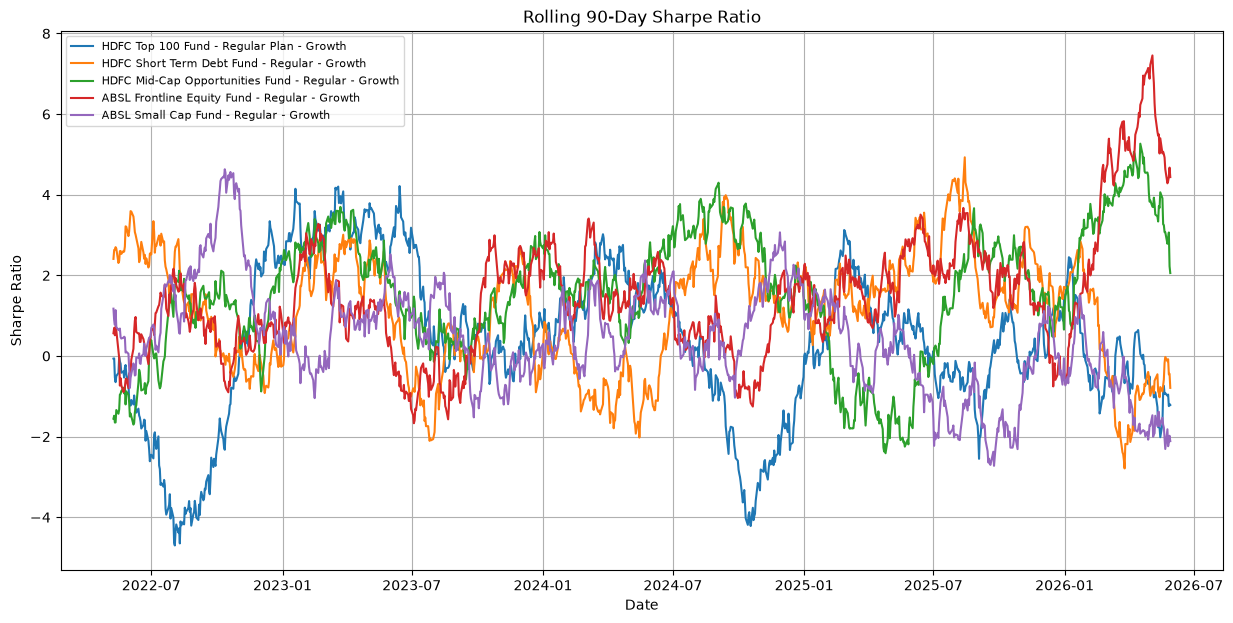

In [163]:
plt.figure(figsize=(15, 7))

for fund_name in top5_funds:

    df = nav[nav["scheme_name"] == fund_name].copy()

    rolling_sharpe = (
        df["daily_return"].rolling(90).mean()
        /
        df["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(df["date"], rolling_sharpe, label=fund_name)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)
plt.savefig("../reports/charts/rolling_sharpe_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [164]:
transactions = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\investor_transactions_clean.csv")

transactions.head(5)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [165]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [166]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  str           
 1   transaction_date    32778 non-null  datetime64[us]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  str           
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  str           
 6   city                32778 non-null  str           
 7   city_tier           32778 non-null  str           
 8   age_group           32778 non-null  str           
 9   gender              32778 non-null  str           
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  str           
 12  kyc_status          32778 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(9)
memory

In [167]:
transactions["transaction_year"] = transactions["transaction_date"].dt.year

first_year = (
    transactions.groupby("investor_id")["transaction_year"]
    .min()
    .reset_index()
)

first_year.rename(
    columns={"transaction_year": "cohort_year"},
    inplace=True
)

first_year.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [168]:
transactions = transactions.merge(
    first_year,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,2024


In [169]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,2024


In [170]:
cohort_summary = (
    sip_transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        total_sip_transactions=("investor_id", "count"),
        unique_investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,total_sip_transactions,unique_investors
0,2024,10996.885825,214978121,19549,4624
1,2025,13505.209581,2255370,167,138


In [171]:
sip_transactions = sip_transactions.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [172]:
top_fund = (
    sip_transactions
    .groupby(["cohort_year", "scheme_name"])
    .size()
    .reset_index(name="sip_count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "sip_count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund

,cohort_year,scheme_name,sip_count
15,2024,ICICI Pru Bluechip Fund - Direct - Growth,536
75,2025,SBI Small Cap Fund - Direct Plan - Growth,8


In [173]:
cohort_summary.to_csv(
    "../data/processed/cohort_summary.csv",
    index=False
)

top_fund.to_csv(
    "../data/processed/cohort_top_fund.csv",
    index=False
)

## SIP Continuity Analysis

In [174]:
sip = transactions[transactions["transaction_type"] == "SIP"].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,2024


In [175]:
sip.info()

<class 'pandas.DataFrame'>
Index: 19716 entries, 0 to 32776
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         19716 non-null  str           
 1   transaction_date    19716 non-null  datetime64[us]
 2   amfi_code           19716 non-null  int64         
 3   transaction_type    19716 non-null  str           
 4   amount_inr          19716 non-null  int64         
 5   state               19716 non-null  str           
 6   city                19716 non-null  str           
 7   city_tier           19716 non-null  str           
 8   age_group           19716 non-null  str           
 9   gender              19716 non-null  str           
 10  annual_income_lakh  19716 non-null  float64       
 11  payment_mode        19716 non-null  str           
 12  kyc_status          19716 non-null  str           
 13  transaction_year    19716 non-null  int32         
 14  cohort

In [176]:
sip["transaction_date"] = pd.to_datetime(sip["transaction_date"])

In [177]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,2024


In [178]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2025,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,2024,28.0


In [179]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

sip_count.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [180]:
eligible_investors = sip_count[
    sip_count["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [181]:
sip_eligible = sip.merge(
    eligible_investors[["investor_id"]],
    on="investor_id",
    how="inner"
)

sip_eligible.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year,gap_days
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,2024,NaN
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,2024,26.0
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,2024,28.0
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,2024,59.0
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2025,2024,265.0


In [182]:
avg_gap = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days", "mean"),
        sip_transactions=("investor_id", "count")
    )
    .reset_index()
)

avg_gap.head()

,investor_id,avg_gap_days,sip_transactions
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [183]:
avg_gap["status"] = avg_gap["avg_gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Healthy"
)

avg_gap.head(10)

,investor_id,avg_gap_days,sip_transactions,status
0,INV000004,85.400000,6,At-Risk
1,INV000008,70.400000,6,At-Risk
2,INV000010,64.800000,6,At-Risk
3,INV000011,40.166667,7,At-Risk
4,INV000012,57.000000,8,At-Risk
5,INV000013,55.333333,7,At-Risk
6,INV000014,75.333333,7,At-Risk
7,INV000023,58.571429,8,At-Risk
8,INV000028,93.600000,6,At-Risk
9,INV000029,60.666667,7,At-Risk


In [184]:
avg_gap.to_csv(
    "../data/processed/sip_continuity_report.csv",
    index=False
)

## Simple fund recommender

In [185]:
sharpe=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\sharpe_ratio.csv")
sharpe.head()

,amfi_code,avg_daily_return,std_daily_return,sharpe_ratio,scheme_name,expense_ratio_pct,sharpe_rank
0,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1.46,1
1,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,1.45,2
2,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,3
3,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,1.54,4
4,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,1.36,5


In [186]:
sharpe.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          40 non-null     int64  
 1   avg_daily_return   40 non-null     float64
 2   std_daily_return   40 non-null     float64
 3   sharpe_ratio       40 non-null     float64
 4   scheme_name        40 non-null     str    
 5   expense_ratio_pct  40 non-null     float64
 6   sharpe_rank        40 non-null     int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 2.3 KB


In [187]:
fund=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\fund_master_clean.csv")
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [188]:
recommendation_data = sharpe.merge(
    fund[["amfi_code", "risk_category"]],
    on="amfi_code",
    how="left"
)

recommendation_data.head()

,amfi_code,avg_daily_return,std_daily_return,sharpe_ratio,scheme_name,expense_ratio_pct,sharpe_rank,risk_category
0,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1.46,1,Moderate
1,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,1.45,2,Moderately High
2,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,3,High
3,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,1.54,4,Moderate
4,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,1.36,5,High


# Sector HHI Concentration

In [189]:
holdings=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\09_portfolio_holdings.csv")
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [190]:
holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [191]:
holdings["portfolio_date"] = pd.to_datetime(holdings["portfolio_date"])
holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   amfi_code          322 non-null    int64         
 1   stock_symbol       322 non-null    str           
 2   stock_name         322 non-null    str           
 3   sector             322 non-null    str           
 4   weight_pct         322 non-null    float64       
 5   market_value_cr    322 non-null    float64       
 6   current_price_inr  322 non-null    float64       
 7   portfolio_date     322 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(1), str(3)
memory usage: 20.3 KB


In [192]:
sector_weights = (
    holdings
    .groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [193]:
sector_weights["weight"] = sector_weights["weight_pct"] / 100

In [194]:
hhi = (
    sector_weights
    .groupby("amfi_code")
    .agg(
        HHI=("weight", lambda x: (x**2).sum())
    )
    .reset_index()
)

hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [195]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [196]:
hhi = hhi.merge(
    fund[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

In [197]:
equity_hhi = (
    hhi[hhi["category"] == "Equity"]
    .sort_values("HHI", ascending=False)
)

equity_hhi.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Equity
30,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
27,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
6,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,Equity
32,149323,0.241077,DSP Midcap Fund - Regular - Growth,Equity
21,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth,Equity
10,118635,0.237497,Nippon India ETF Nifty 50 BeES,Equity
18,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth,Equity
22,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity


In [198]:
equity_hhi.to_csv("../data/processed/sector_hhi.csv", index=False)

In [199]:
var_cvar=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\var_cvar_report.csv")

# 5 advanced insights

In [200]:
var_cvar.sort_values("VaR_95").head(5)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595


In [201]:
top_var = (
    var_cvar
    .merge(
        fund[["amfi_code", "scheme_name"]],
        on="amfi_code",
        how="left"
    )
    .sort_values("VaR_95")
)

top_var.head(5)

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth


## 1. Historical VaR & CVaR Analysis

The **SBI Small Cap Fund - Direct Plan - Growth** recorded the highest downside risk among all analyzed funds, with a **95% VaR of -2.69%** and a **CVaR of -3.24%**. This indicates that during the worst market conditions, the fund experienced the largest potential losses compared to other schemes.

## 2. Rolling 90-Day Sharpe Ratio

The rolling 90-day Sharpe Ratio showed that **ABSL Frontline Equity Fund - Regular - Growth** achieved the highest risk-adjusted performance, reaching a Sharpe Ratio of approximately **7.5** during the analysis period. In contrast, **HDFC Top 100 Fund - Regular Plan - Growth** exhibited the largest fluctuations, with Sharpe Ratios ranging from around **-4.8** to above **4.0**, indicating greater variability in risk-adjusted returns.

## 3. Investor Cohort Analysis

The **2024 investor cohort** dominated the dataset, contributing **4,624 unique investors**, **19,549 SIP transactions**, and a total investment of **₹214,978,121**. Although the **2025 cohort** had a higher average SIP amount (**₹13,505.21** vs **₹10,996.89**), it consisted of only **138 investors** and **167 SIP transactions**, making its overall contribution significantly smaller than the 2024 cohort.

In [202]:
sip_report=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\sip_continuity_report.csv")

In [203]:
sip_report["status"].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

## 4. SIP Continuity Analysis

The SIP continuity analysis showed that **1,332 investors** were classified as **At-Risk**, as their average gap between SIP installments exceeded **35 days**. Only **30 investors** were classified as **Healthy**, indicating that most investors with six or more SIP transactions had irregular investment patterns. These findings can help asset management companies identify investors who may benefit from timely reminders or engagement strategies to improve SIP continuity.

## 5. Sector HHI Concentration

The Sector Herfindahl–Hirschman Index (HHI) analysis showed that **Axis Bluechip Fund - Regular - Growth** had the highest sector concentration among all analyzed equity funds, with an **HHI of 0.296769**. This indicates that the fund allocates a larger proportion of its portfolio to a limited number of sectors, whereas funds with lower HHI values are more diversified across multiple sectors.